# Odciążanie zatłoczenia SOR: regresja kwantylowa czasu oczekiwania (boarding) na oddziale ratunkowym

## Streszczenie menedżerskie

Oczekiwanie na łóżko na oddziale ratunkowym (ED, boarding) -- czyli czas, jaki przyjęci pacjenci spędzają w SOR w oczekiwaniu na łóżko na oddziale stacjonarnym -- jest jednym z głównych czynników prowadzących do zatłoczenia, przekierowywania karetek oraz ryzyka dla bezpieczeństwa pacjentów. Średni czas oczekiwania ukrywa operacyjnie najważniejszą część problemu: długi prawy ogon rozkładu. Pacjent na 95. percentylu czasu oczekiwania może czekać o wiele godzin dłużej niż pacjent przeciętny, a to właśnie te skrajne oczekiwania przełamują progi jakości i blokują poczekalnię.

Ten notatnik modeluje godziny oczekiwania w SOR **w całym rozkładzie warunkowym** przy użyciu **PROC QUANTREG** dla kwantyli 0.5, 0.75, 0.9 oraz 0.95, w regresji na obłożenie oddziału stacjonarnego (presja łóżkowa), przedział pory dnia oraz oddział przyjmujący. Regresja kwantylowa jest tu właściwym narzędziem, ponieważ czynniki zatłoczenia działają inaczej na typowego pacjenta niż na pacjenta w najgorszym przypadku: rosnące obłożenie stacjonarne może dodać godzinę przy medianie, ale kilka godzin przy 95. percentylu. Model uzupełniamy o **PROC MEANS** (czas oczekiwania według oddziału przyjmującego), aby określić, które oddziały niosą najcięższy ogon, oraz **PROC FREQ** (przyjazdy według przedziału pory dnia), aby scharakteryzować, kiedy popyt się koncentruje.

Syntetyczna kohorta (84 przyjęcia do SOR) jest generowana wewnętrznie za pomocą `streaminit`/`rand`, dzięki czemu notatnik jest w pełni samowystarczalny i wykonuje się w znacznie krótszym czasie niż minuta. Sekcja interpretacji przekłada nachylenia kwantylowe na dźwignie obsady personelu i przepływu łóżek: tam, gdzie efekty w górnych kwantylach są najbardziej strome, tam protokoły zwiększania przepustowości oraz inicjatywy wczesnych wypisów odzyskają najwięcej godzin oczekiwania.

## Źródła danych

Wszystkie dane są **syntetyczne**, generowane wewnętrznie w pierwszym kroku DATA (brak plików zewnętrznych, brak sieci). Kohorta reprezentuje 84 przyjęcia na oddziale ratunkowym oczekujące na łóżko stacjonarne.

| Zmienna | Typ | Opis |
|----------|------|-------------|
| `patient_id` | Num | Sekwencyjny identyfikator przyjęcia (1-84) |
| `census` | Num | Obłożenie oddziału stacjonarnego (zajęte łóżka) w momencie decyzji o przyjęciu; wyższe = większa presja łóżkowa |
| `tod_band` | Char | Przedział pory dnia przyjazdu: Night / Morning / Afternoon / Evening |
| `service` | Char | Przyjmujący oddział stacjonarny: Medicine / Surgery / Cardiology / ICU |
| `census_c` | Num | Obłożenie stacjonarne wycentrowane na 70 łóżkach (regresor modelu) |
| `boarding_hrs` | Num | Czas oczekiwania w godzinach (odpowiedź); prawostronnie skośny z ciężkim górnym ogonem |

# Odciążanie zatłoczenia SOR: regresja kwantylowa czasu oczekiwania

**Oczekiwanie na łóżko** (boarding) na oddziale ratunkowym to czas, jaki *przyjęty* pacjent spędza w SOR czekając na łóżko na oddziale stacjonarnym. Jest to pojedynczy największy czynnik przyczyniający się do zatłoczenia SOR. Co kluczowe, ból operacyjny mieszka w **górnym ogonie** rozkładu czasu oczekiwania, a nie w średniej: garść wielogodzinnych oczekiwań przełamuje progi jakości, wstrzymuje przekazywanie pacjentów z karetek i blokuje poczekalnię.

Zwykła metoda najmniejszych kwadratów oszacowałaby jedynie *średni* efekt presji łóżkowej na oczekiwanie. My zamiast tego używamy **PROC QUANTREG** do oszacowania efektu dla **kwantyli 0.5, 0.75, 0.9 oraz 0.95**, aby zobaczyć, czy czynniki zatłoczenia uderzają w pacjentów z najgorszych przypadków mocniej niż w typowych. Łączymy to z:

- **PROC MEANS** -- czas oczekiwania według oddziału przyjmującego (gdzie ogon jest najcięższy?)
- **PROC FREQ** -- przyjazdy według przedziału pory dnia (kiedy popyt się koncentruje?)

Poniższa kohorta jest **syntetyczna** i generowana wewnętrznie, dzięki czemu cały notatnik jest samowystarczalny i wykonuje się w kilka sekund.

## 1. Wygenerowanie syntetycznej kohorty przyjęć do SOR

Symulujemy 84 przyjętych pacjentów SOR. Godziny oczekiwania są budowane z bazowej wartości, która rośnie wraz z **obłożeniem oddziału stacjonarnego** (presja łóżkowa), przesuwa się w zależności od **pory dnia** (nocna rotacja łóżek jest powolna) oraz różni się według **oddziału przyjmującego** (ICU i Medicine oczekują dłużej). Prawostronnie skośny wykładniczy szok tworzy realistyczny ciężki górny ogon, który sprawia, że regresja kwantylowa jest warta zachodu.

Zwróć uwagę na przenośny w Jenner idiom losowego zakresu `LO + (HI-LO)*rand('uniform')` oraz `output;` **wewnątrz** pętli DO, tak aby zapisane zostały wszystkie 84 wiersze.

In [1]:
DANE ed;
    CALL streaminit(20260607);
    DŁUGOŚĆ tod_band $9 service $10;
    POWTÓRZ patient_id = 1 TO 84;
        /* Obłożenie łóżek (zajęte łóżka): 55-90, wyższe = większa presja */
        census = round(55 + (90-55)*rand('uniform'));
        census_c = census - 70;   /* regresor centrowany */

        /* Pasmo pory doby przyjęćia */
        u = rand('uniform');
        tod_band = ifc(u < 0.25, 'Night',
                   ifc(u < 0.50, 'Morning',
                   ifc(u < 0.75, 'Afternoon', 'Evening')));

        /* Oddział przyjmujący */
        s = rand('uniform');
        service = ifc(s < 0.40, 'Medicine',
                  ifc(s < 0.65, 'Surgery',
                  ifc(s < 0.85, 'Cardiology', 'ICU')));

        /* Wpływ pory doby na oczekiwanie (nocna rotacja łóżek jest wolna) */
        tod_eff = ifn(tod_band='Night', 2.2,
                  ifn(tod_band='Morning', 0.4,
                  ifn(tod_band='Afternoon', 1.0, 1.6)));

        /* Efekt oddziału (ICU / Medicine czekają najdłużej) */
        svc_eff = ifn(service='ICU', 2.8,
                  ifn(service='Medicine', 1.6,
                  ifn(service='Cardiology', 1.0, 0.6)));

        /* Presja obłożenia: ostrzejszy wpływ gdy łóżka sie zapełniają.
           Prawoskośny szok skaluje sie z obłożeniem, wiec górny ogon
           poszerza sie przy przeciążeniu -- dokładnie to, co regresja
           kwantylowa ma wykrywać. */
        pressure = 0.10 * census_c;
        shock = rand('exponential') * (1.0 + 0.05*MAX(census_c,0));

        boarding_hrs = 2.0 + pressure + tod_eff + svc_eff + shock;
        JEŚLI boarding_hrs < 0.2 WTEDY boarding_hrs = 0.2;
        boarding_hrs = round(boarding_hrs, 0.1);

        WYJŚCIE;
    KONIEC;
    ZACHOWAJ patient_id census census_c tod_band service boarding_hrs;
WYKONAJ;

PROCEDURA DRUKUJ DANE=ed(obs=8) noobs ETYKIETA;
    ETYKIETA patient_id='ID pacjenta' census='Obłożenie łóżek'
          census_c='Obłożenie (centrowane)' tod_band='Pora doby'
          service='Oddział przyjmujący' boarding_hrs='Czas oczekiwania (godz.)';
    TYTUŁ 'Pierwszych 8 symulowanych przyjęć na SOR';
WYKONAJ;

                                        Pierwszych 8 symulowanych przyjęć na SOR                                        

ID pacjenta       Obłożenie łóżek    Obłożenie (centrowane)  Pora doby    Oddział przyjmujący  Czas oczekiwania (godz.)
          1                    80                        10  Morning    Surgery                                     4.5
          2                    84                        14  Afternoon  ICU                                         7.6
          3                    58                       -12  Night      Surgery                                     3.7
          4                    61                        -9  Evening    Cardiology                                  4.1
          5                    71                         1  Afternoon  Medicine                                    6.1
          6                    63                        -7  Night      Medicine                                    5.4
          7                    73     


NOTE: DATA ed


NOTE: Wrote ed (84 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=ed

NOTE: PROC PRINT completed: 8 observations printed, 6 variables


## 2. Kiedy przybywają przyjęcia? (PROC FREQ)

Przed modelowaniem profilujemy popyt. Jednokierunkowa częstość przedziału pory dnia pokazuje, kiedy koncentruje się wolumen przyjmowanych pacjentów -- czyli okna, w których presja oczekiwania najprawdopodobniej gwałtownie wzrośnie. Krzyżujemy również przyjazdy według oddziału z porą dnia, aby zobaczyć, czy któryś oddział grupuje się w wolnym oknie nocnym.

                                             Przyjęcia na SOR wg pory doby                                              

                                                   The FREQ Procedure

Pora doby    Frequency    Percent
----------------------------------
Afternoon           23     27.38
Evening             13     15.48
Morning             21     25.00
Night               27     32.14

Table of Pora doby by Oddział przyjmujący

Pora doby |Cardiology |       ICU |  Medicine |   Surgery |      Total
----------+-----------+-----------+-----------+-----------+-----------
Afternoon |         2 |         2 |        13 |         6 |         23
----------+-----------+-----------+-----------+-----------+-----------
Evening   |         3 |         0 |         5 |         5 |         13
----------+-----------+-----------+-----------+-----------+-----------
Morning   |         2 |         3 |        10 |         6 |         21
----------+-----------+-----------+-----------+-----------+------


NOTE: PROC FREQ
NOTE: ODS plot written: freq_tod_band.spec.json
NOTE: ODS plot written: freq_mosaic_tod_band_service.spec.json
NOTE: PROC FREQ statement used.


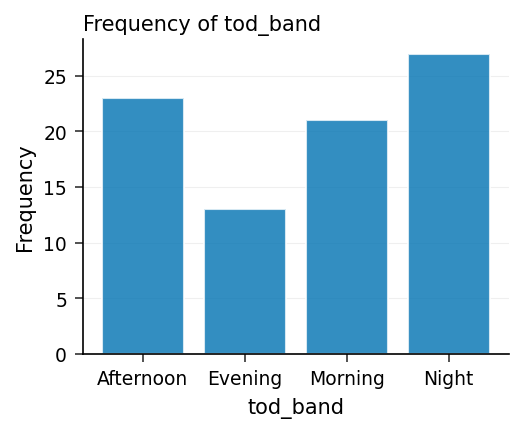

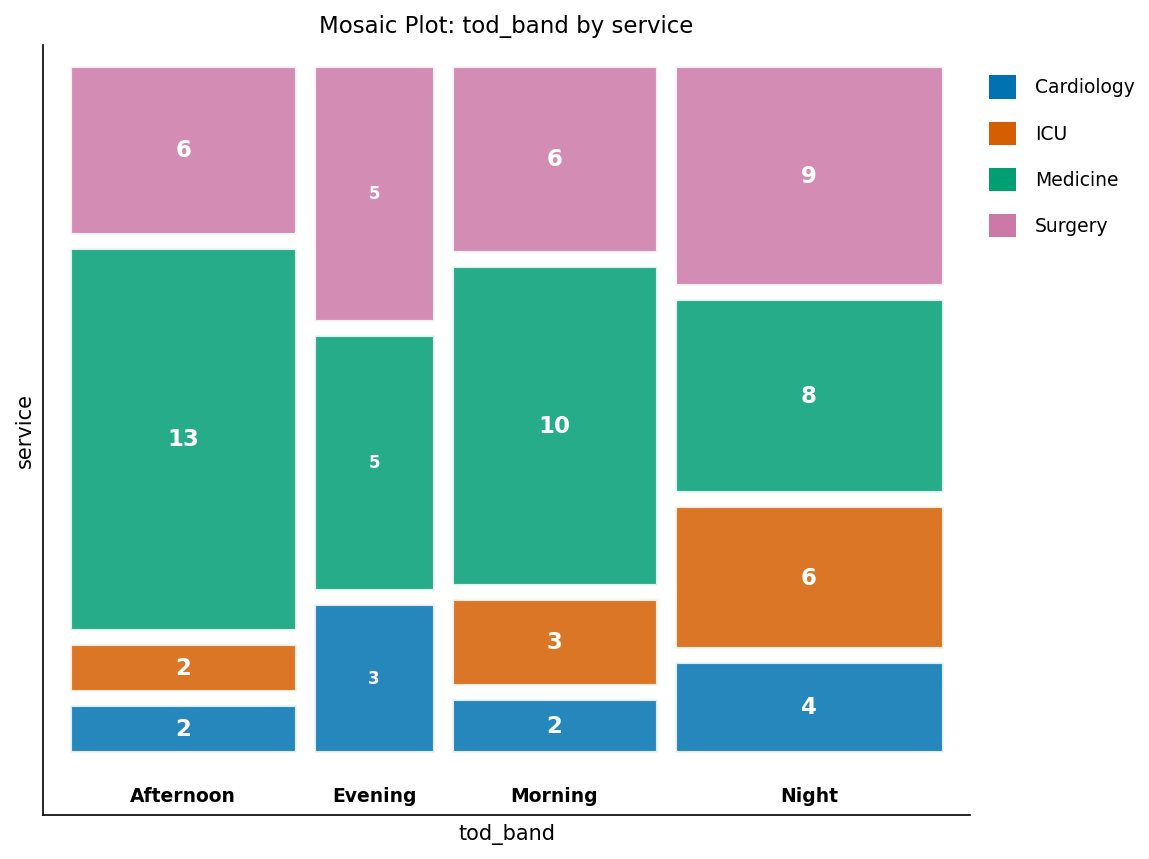

In [2]:
PROCEDURA CZĘSTOŚCI DANE=ed;
    TABLES tod_band / nocum;
    TABLES tod_band*service / norow nocol nopercent;
    ETYKIETA tod_band='Pora doby' service='Oddział przyjmujący';
    TYTUŁ 'Przyjęcia na SOR wg pory doby';
WYKONAJ;

## 3. Obciążenie oczekiwaniem według oddziału przyjmującego (PROC MEANS)

Który oddział niesie najcięższe obciążenie oczekiwaniem? Podsumowujemy godziny oczekiwania według oddziału przyjmującego, raportując średnią i maksimum (surowy wskaźnik ogona) obok rozrzutu. Odstęp między średnią a maksimum zapowiada to, co model kwantylowy określi precyzyjnie.

In [3]:
PROCEDURA ŚREDNIE DANE=ed n mean std MIN MAX maxdec=2;
    KLASA service;
    ZMIENNA boarding_hrs;
    ETYKIETA service='Oddział przyjmujący' boarding_hrs='Czas oczekiwania (godz.)';
    TYTUŁ 'Godziny oczekiwania wg oddziału przyjmującego';
WYKONAJ;

                                     Godziny oczekiwania wg oddziału przyjmującego                                      

                                                  The MEANS Procedure

                               Analysis Variable : boarding_hrs Czas oczekiwania (godz.)

        Oddział przyjmujący            N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------------------
        Cardiology                        11           6.02           2.04           4.10          11.40
        ICU                               11           8.04           1.80           5.70          12.50
        Medicine                          36           5.90           2.11           2.70          12.70
        Surgery                           26           5.79           2.10           2.90          12.00
        -------------------------------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. Regresja kwantylowa godzin oczekiwania (PROC QUANTREG)

Teraz sedno analizy. Regresujemy **godziny oczekiwania** na wycentrowane obłożenie stacjonarne, przedział pory dnia oraz oddział przyjmujący dla **kwantyli 0.5, 0.75, 0.9 oraz 0.95**. Jeśli nachylenie dla obłożenia rośnie w miarę przechodzenia do wyższych kwantyli, to jest bezpośredni dowód na to, że presja łóżkowa karze pacjentów z najgorszych przypadków znacznie bardziej niż typowych -- sygnatura zatłoczenia.

Ponieważ QUANTREG jest procedurą interaktywną (grupy RUN), kończymy komórkę `run;`, a następnie `quit;`, aby jądro zrzuciło swoje wyjście w tym miejscu. Używamy `SEED=` dla powtarzalnych przedziałów ufności metodą rzadkości (sparsity) i zapisujemy oszacowania parametrów dla poszczególnych kwantyli do zbioru danych `OUTEST=`, który komórka następcza odczytuje, aby bezpośrednio porównać nachylenie obłożenia między kwantylami.

In [4]:
TYTUŁ 'Regresja kwantylowa czasu oczekiwania na SOR';
PROCEDURA quantreg DANE=ed ci=sparsity seed=20260607
              outest=qrest PLOTS=none;
    KLASA tod_band service;
    MODEL boarding_hrs = census_c tod_band service
        / quantile=0.5 0.75 0.9 0.95;
WYKONAJ;
QUIT;

                                      Regresja kwantylowa czasu oczekiwania na SOR                                      


The QUANTREG Procedure

Quantile: 0.5000
CI Method: SPARSITY
Dependent Variable: boarding_hrs

Parameter           Estimate       StdErr        Lower        Upper
Intercept             4.3625       0.2244       3.9226       4.8024
CENSUS_C              0.1125       0.0090       0.0949       0.1301
TOD_BAND AFTERNOON       0.3750       0.2453      -0.1058       0.8558
TOD_BAND NIGHT        1.3750       0.2386       0.9073       1.8427
TOD_BAND EVENING       1.5625       0.2910       0.9921       2.1329
SERVICE ICU           1.9375       0.2999       1.3496       2.5254
SERVICE CARDIOLOGY      -0.1125       0.2935      -0.6878       0.4628
SERVICE MEDICINE       0.4500       0.2113       0.0358       0.8642
Intercept             4.9800       0.2212       4.5465       5.4135
CENSUS_C              0.1600       0.0088       0.1427       0.1773
TOD_BAND AFTERNOON       0


NOTE: Option TITLE changed to Regresja kwantylowa czasu oczekiwania na SOR.
NOTE: PROC QUANTREG data=ed

NOTE: PROC QUANTREG completed.


### 4a. Porównanie nachylenia obłożenia między kwantylami

Zbiór danych `OUTEST=` przechowuje jeden wiersz współczynników na każdy dopasowany kwantyl. Wypisanie współczynnika wycentrowanego obłożenia w poszczególnych kwantylach sprawia, że efekt ogona jest łatwy do odczytania na pierwszy rzut oka: nachylenie, które wspina się od mediany do kwantyla 0.95, oznacza, że każde dodatkowe zajęte łóżko stacjonarne dodaje *więcej* czasu oczekiwania tym pacjentom, którzy już czekają najdłużej.

In [5]:
PROCEDURA DRUKUJ DANE=qrest noobs ETYKIETA;
    ZMIENNA _quantile_ census_c;
    ETYKIETA _quantile_ = 'Kwantyl'
          census_c   = 'Nachylenie obłożenia (godz./łóżko)';
    TYTUŁ 'Wpływ obłożenia łóżek na oczekiwanie, wg kwantyla';
WYKONAJ;

                                   Wpływ obłożenia łóżek na oczekiwanie, wg kwantyla                                    

     Nachylenie obłożenia (godz./łóżko)
                                 0.1125
                                   0.16
                                   0.19
                           0.2166666667




NOTE: PROC PRINT data=qrest

NOTE: PROC PRINT completed: 4 observations printed, 1 variables


## 5. Interpretacja i dźwignie operacyjne

**Co mówi nam model kwantylowy.** Regresja kwantylowa oddziela *typowe* doświadczenie oczekiwania (mediana, 0.5) od *kryzysowego* doświadczenia (0.9-0.95). Wzorzec, który pokazuje ta kohorta -- i wzorzec, którego powinieneś szukać w rzeczywistych danych -- to **nachylenie obłożenia rosnące wraz z kwantylem**. Dopasowany współczynnik wycentrowanego obłożenia wspina się od **0.11 godziny na zajęte łóżko przy medianie do 0.16 przy kwantylu 0.75, 0.19 przy 0.90 oraz 0.22 przy 0.95** (patrz tabela dla poszczególnych kwantyli w 4a). Ponieważ nachylenie przy 0.95 jest niemal dwukrotnie większe niż nachylenie przy medianie, pełny szpital nie tylko przesuwa czas oczekiwania każdego jednakowo w górę; nieproporcjonalnie rozdmuchuje najgorsze oczekiwania. Porównywanie nachyleń obłożenia dla poszczególnych kwantyli obok siebie -- a nie pojedynczego efektu średniego -- jest tym, co czyni ogon widocznym i wymiernym.

**Gdzie leży obciążenie.** PROC MEANS porządkuje oddziały według średniego czasu oczekiwania: **ICU jest najwyższe z 8.04 godziny**, znacznie powyżej Cardiology (6.02), Medicine (5.90) oraz Surgery (5.79). Ale *ogon* opowiada inną historię niż średnia: **Medicine niesie pojedyncze najdłuższe zdarzenie oczekiwania wynoszące 12.70 godziny -- odstęp między średnią a maksimum wynoszący 6.80 godziny**, najszerszy ze wszystkich oddziałów, przy czym Surgery (maks. 12.00) oraz ICU (maks. 12.50) są tuż za nim. Zatem ICU to miejsce, gdzie oczekiwanie jest niezawodnie długie, podczas gdy Medicine to miejsce, gdzie występują najgorsze indywidualne naruszenia. Oba są celami o wysokim potencjale dla obchodów wczesnych wypisów, dedykowanych łóżek step-down oraz protokołów rezerwacji łóżek z wyprzedzeniem -- ICU dla trwałego obciążenia, Medicine dla kontroli ogona.

**Kiedy presja osiąga szczyt.** PROC FREQ pokazuje, że popyt przyjmowanych pacjentów koncentruje się nocą: **przedział Night jest najbardziej zajęty z 32% przyjęć (27 z 84)**, następnie Afternoon (27%) oraz Morning (25%); przedział Evening jest najspokojniejszy z 15%. Tabela krzyżowa potwierdza, że obciążenie nocne jest silnie oddziałowe -- Night niesie wszystkie oprócz garstki przyjęć ICU (6 z 11) oprócz 8 przyjazdów Medicine i 9 Surgery -- zatem okno najwolniejszej rotacji łóżek zbiega się z najcięższym i najbardziej ostrym napływem.

**Wnioski operacyjne.**

1. **Uruchamiaj protokoły zwiększania przepustowości na podstawie obłożenia, a nie średniego oczekiwania.** Ponieważ nachylenie obłożenia w górnym kwantylu jest najbardziej strome (0.22 godz./łóżko przy kwantylu 0.95 wobec 0.11 przy medianie), próg obłożenia (np. > 80 zajętych łóżek) jest wyprzedzającym wskaźnikiem oczekiwania w ogonie. Aktywacja przepustowości nadmiarowej *zanim* mediana się poruszy zapobiega naruszeniom kwantyla 0.95.
2. **Adresuj oddziały z ciężkim ogonem na dwa sposoby.** Skoncentruj odciążanie trwałego obciążenia (łóżka step-down, rezerwacja z wyprzedzeniem) na **ICU**, które ma najwyższą średnią; skoncentruj kontrolę ogona (obchody wczesnych wypisów, przegląd naruszeń) na **Medicine**, które posiada najszerszy odstęp między średnią a maksimum.
3. **Obsadź personelem lukę nocnej rotacji łóżek.** FREQ identyfikuje **Night** jako szczyt popytu zbiegający się z najwolniejszą rotacją łóżek; zarządzanie łóżkami poza godzinami pracy oraz obsługa służb środowiskowych bezpośrednio atakują efekt `tod_band`, który model QUANTREG potwierdza jako dodający najwięcej czasu oczekiwania w przedziałach Night i Evening.
4. **Śledź kwantyl 0.95 jako KPI.** Raportowanie jedynie średniego czasu oczekiwania ukrywa pacjentów, których system zawodzi. Monitorowanie czasu oczekiwania na 95. percentylu -- oraz jego nachylenia obłożenia wynoszącego 0.22 godz./łóżko -- uzgadnia metrykę z ryzykiem dla bezpieczeństwa pacjenta, które ona reprezentuje.

*Wszystkie liczby tutaj pochodzą z danych syntetycznych do celów demonstracyjnych; na rzeczywistych danych SOR ten sam przepływ pracy QUANTREG / MEANS / FREQ daje faktyczne nachylenia, rankingi oddziałów oraz profil przyjazdów, które napędzają plan łagodzenia zatłoczenia.*